In [2]:
import numpy as np
import pandas as pd

np.set_printoptions(legacy='1.25') #formatting

# Data Visualisation

import matplotlib.pyplot as plt

#mounting google drive
from google.colab import drive
drive.mount('/content/drive')

#Get file from google drive from D3, load into panda
#Could also read from github directly via a link
#Separate X:input and Y: Ground Truths from dataset

Mounted at /content/drive


In [3]:
#load D3 dataset file and put into panda
file_path = '/content/drive/My Drive/ECGR4105/D3.csv'
#raw dataset dataframe
df = pd.DataFrame(pd.read_csv(file_path))
df.head()

,X1,X2,X3,Y
0,0.000000,3.440000,0.440000,4.387545
1,0.040404,0.134949,0.888485,2.679650
2,0.080808,0.829899,1.336970,2.968490
3,0.121212,1.524848,1.785455,3.254065
4,0.161616,2.219798,2.233939,3.536375


In [4]:
# Linear regression
# Parameters:
# X-2D Array where each row represent the training example and each column represnts the future
#   M = the number of training examples
#   N = the number of features (including X_0 column of ones)
# Y-1D array of labels/target values for each training example (m)
# Theta-1D array of fitting parameters or weighs (n)
#Returns:
# J: scalar value, the cost
def compute_cost(X, y, theta):

    predictions = X.dot(theta)
    errors = np.subtract(predictions, y)
    sqrErrors = np.square(errors)
    J = 1 / (2 * m) * np.sum(sqrErrors)

    return J


#gradient decent
#
# Parameters:
# X : 2-D m & n
# y : Labels/target values
# alpha : learning rate
# iterations:number of iterations
# Return:
# theta : upated parameter/weight after iterations (n)
# cost history : array containing the cost of ech iteration

# using a tensor with numpy
def gradient_descent(X, y, theta, alpha, iterations):
  m = len(y)
  cost_history = np.zeros(iterations)

  for i in range(iterations):
    predictions = X.dot(theta)
    errors = np.subtract(predictions, y)
    sum_delta = (alpha/m) * X.transpose().dot(errors)
    theta -= sum_delta
    cost_history[i] = compute_cost(X, y, theta)

  return theta, cost_history




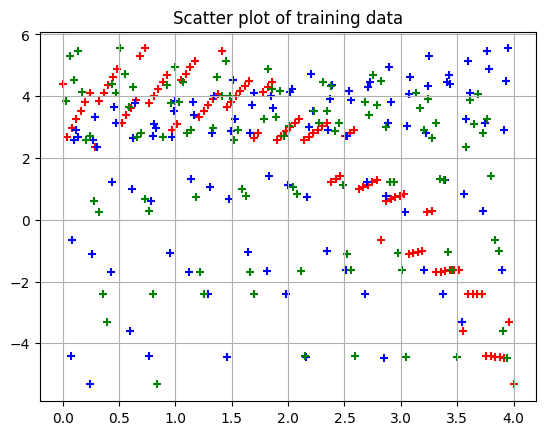

In [5]:
x = df.values[:, 0:3]
x1 = df.values[:,0]
x2 = df.values[:,1]
x3 = df.values[:,2]
Y = df.values[:,3]
m = len(Y)
n = len(x)

# Scatter plot
plt.scatter(x1, Y, color='red', marker='+')
plt.scatter(x2, Y, color='blue', marker='+')
plt.scatter(x3, Y, color='green', marker='+')

# Grid, labels, and title
plt.grid(True)
plt.rcParams["figure.figsize"] = (6, 6)
plt.title('Scatter plot of training data')
plt.show()


In [20]:
# y = θ + θ1x1 + θ2x2 + θ3x3 split into its components

x0 = np.ones((m, 1)) # starting bias column of 1
X1 = np.hstack((x0.reshape(m, 1), x1.reshape(m, 1)))
X2 = np.hstack((x0.reshape(m, 1), x2.reshape(m, 1)))
X3 = np.hstack((x0.reshape(m, 1), x3.reshape(m, 1)))
theta0 = np.zeros(2)
theta1 = np.zeros(2)
theta2 = np.zeros(2)
theta3 = np.zeros(2)

#since theta is only dependent on the training data or ground truths
cost = compute_cost(X1, Y, theta0)
print(f"cost = {cost}")

iterations = 1000
alpha = 0.1

theta1, cost_history1 = gradient_descent(X1, Y, theta1, alpha, iterations)
theta2, cost_history2 = gradient_descent(X2, Y, theta2, alpha, iterations)
theta3, cost_history3 = gradient_descent(X3, Y, theta3, alpha, iterations)

print("-" * 44)
print(f"{'x1':<10}{theta1[0]:>10.4f}{theta1[1]:>10.4f}{cost_history1[-1]:>14.4f}")
print(f"{'x2':<10}{theta2[0]:>10.4f}{theta2[1]:>10.4f}{cost_history2[-1]:>14.4f}")
print(f"{'x3':<10}{theta3[0]:>10.4f}{theta3[1]:>10.4f}{cost_history3[-1]:>14.4f}")
print("-" * 44)
print(f"y = {theta1[0]:.4f} + {theta1[1]:.4f} * x1")
print(f"y = {theta2[0]:.4f} + {theta2[1]:.4f} * x2")
print(f"y = {theta3[0]:.4f} + {theta3[1]:.4f} * x3")

cost = 5.524438459196242
--------------------------------------------
x1            5.9279   -2.0383        0.9850
x2            0.7361    0.5576        3.5994
x3            2.8714   -0.5205        3.6295
--------------------------------------------
y = 5.9279 + -2.0383 * x1
y = 0.7361 + 0.5576 * x2
y = 2.8714 + -0.5205 * x3


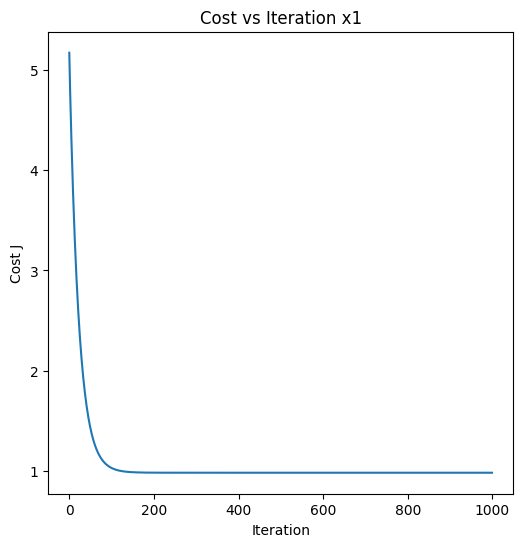

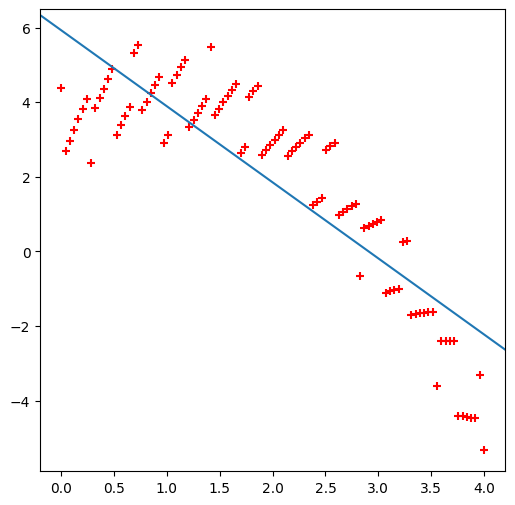

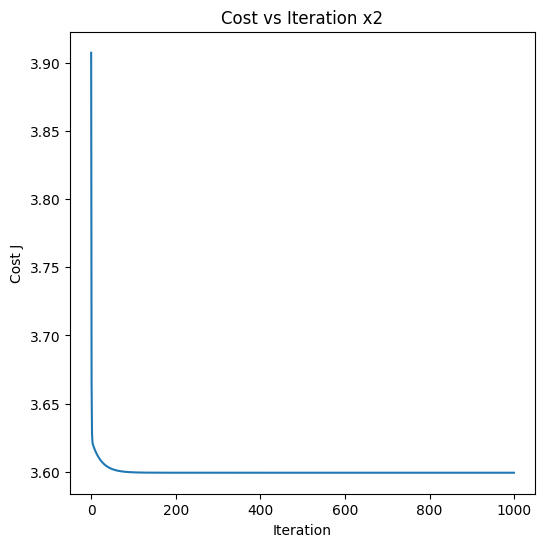

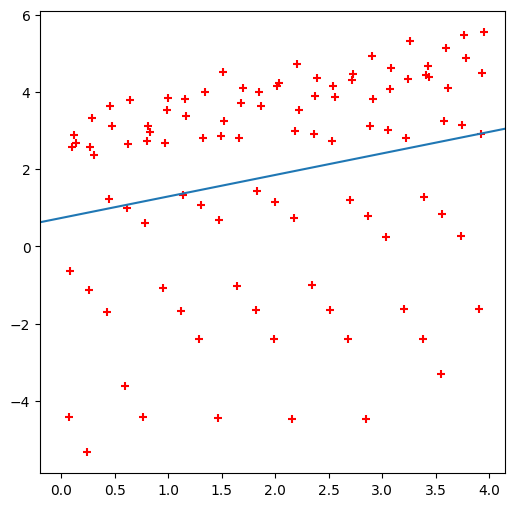

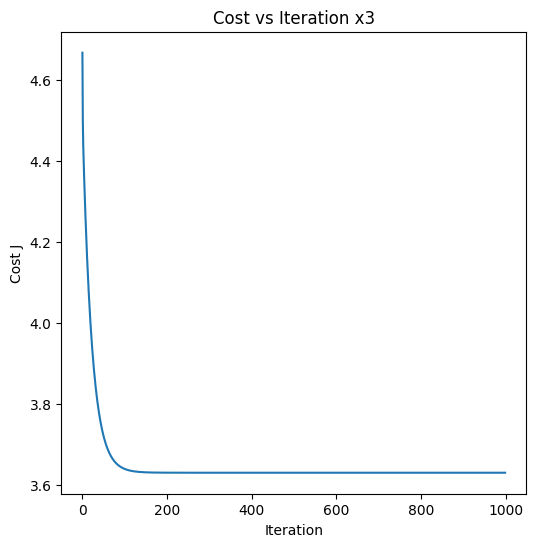

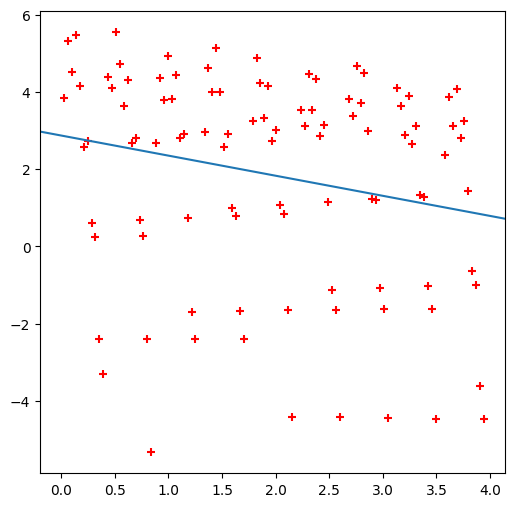

In [14]:
# Cost Plot x1
plt.figure()
plt.plot(cost_history1)
plt.title(f"Cost vs Iteration x1")
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.show()

# Regression fit x1
plt.figure()
plt.scatter(x1, Y, color='red', marker='+')
plt.axline((0, theta1[0]), slope=theta1[1])

plt.figure()
plt.plot(cost_history2)
plt.title(f"Cost vs Iteration x2")
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.show()

plt.figure()
plt.scatter(x2, Y, color='red', marker='+')
plt.axline((0, theta2[0]), slope=theta2[1])

plt.figure()
plt.plot(cost_history3)
plt.title(f"Cost vs Iteration x3")
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.show()

plt.figure()
plt.scatter(x3, Y, color='red', marker='+')
plt.axline((0, theta3[0]), slope=theta3[1])
plt.show()






In [8]:
lowestCosts = [min(cost_history1),min(cost_history2),min(cost_history3)]
print(lowestCosts)
print("lowest cost: " + str(min(lowestCosts)))


[0.9849930825405943, 3.599366018168041, 3.629451124607914]
lowest cost: 0.9849930825405943


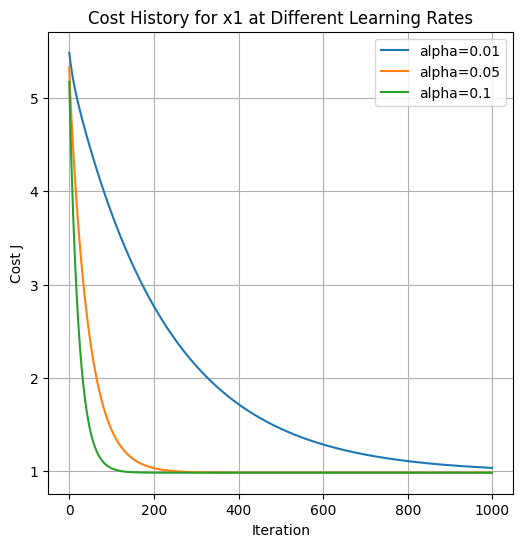

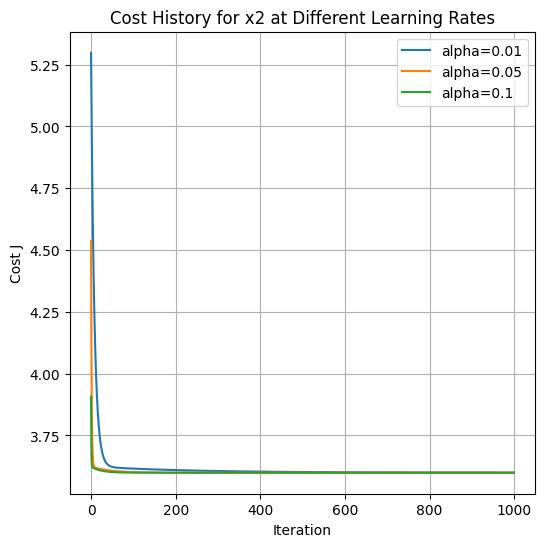

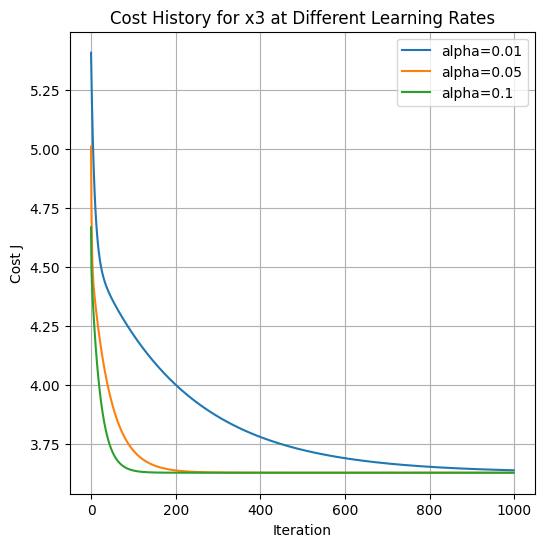

alpha=0.01, x1: final cost=1.0364
alpha=0.05, x1: final cost=0.9850
alpha=0.1, x1: final cost=0.9850
alpha=0.01, x2: final cost=3.5997
alpha=0.05, x2: final cost=3.5994
alpha=0.1, x2: final cost=3.5994
alpha=0.01, x3: final cost=3.6397
alpha=0.05, x3: final cost=3.6295
alpha=0.1, x3: final cost=3.6295


In [9]:
alphas = [0.01, 0.05, 0.1]
inputs = {"x1": X1, "x2": X2, "x3": X3}
results = {}

for name, xin in inputs.items():
    plt.figure()
    cost_histories = []

    for a in alphas:
        theta_init = np.zeros(2)
        t, c = gradient_descent(xin, Y, theta_init, a, iterations)
        cost_histories.append((a, c))
        results[(a, name)] = c[-1]

    for a, c in cost_histories:
        plt.plot(c, label=f"alpha={a}")

    plt.title(f"Cost History for {name} at Different Learning Rates")
    plt.xlabel("Iteration")
    plt.ylabel("Cost J")
    plt.legend()
    plt.grid(True)
    plt.show()

for (a, name), cost in results.items():
    print(f"alpha={a}, {name}: final cost={cost:.4f}")

theta = [ 5.31416563 -2.00371905  0.53256359 -0.26560164]
final cost = 0.7385


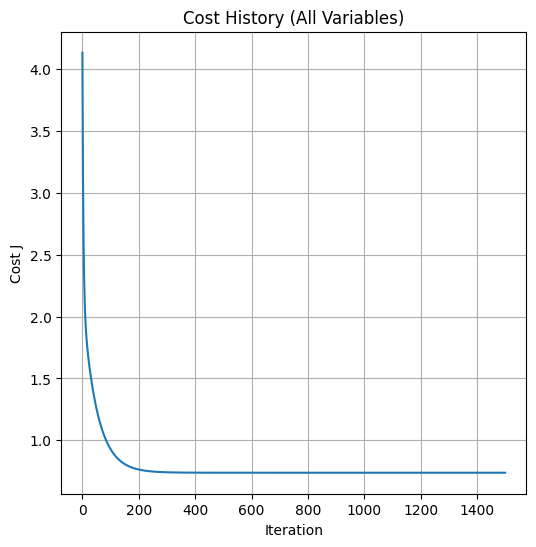

In [10]:
# already created x0
# y = θ0 + θ1x1 + θ2x2 + θ3x3
X_123 = np.hstack((x0.reshape(m, 1), x1.reshape(m, 1), x2.reshape(m, 1), x3.reshape(m, 1)))
theta_init = np.zeros(4) # m , b1 , b2 , b3

iterations = 1500
alpha = 0.1

theta_123, cost_history_123 = gradient_descent(X_123, Y, theta_init, alpha, iterations)

print(f"theta = {theta_123}")
print(f"final cost = {cost_history_123[-1]:.4f}")

plt.figure()
plt.plot(cost_history_123)
plt.title("Cost History (All Variables)")
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.grid(True)
plt.show()

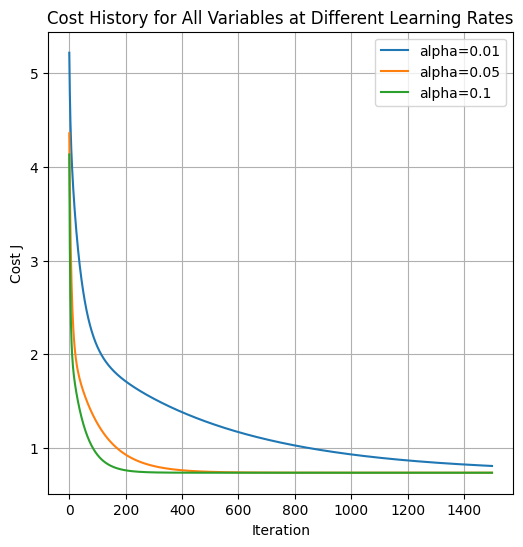

alpha=0.01: final cost=0.8105
alpha=0.05: final cost=0.7385
alpha=0.1: final cost=0.7385


In [11]:
alphas = [0.01, 0.05, 0.1]
results2 = {}

plt.figure() #combined figure
for a in alphas:
    theta_init = np.zeros(4)
    t, c = gradient_descent(X_123, Y, theta_init, a, iterations)
    results2[a] = c[-1]
    plt.plot(c, label=f"alpha={a}")

plt.title("Cost History for All Variables at Different Learning Rates")
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.legend()
plt.grid(True)
plt.show()

for a, cost in results2.items():
    print(f"alpha={a}: final cost={cost:.4f}")

In [12]:
#new prediction

#[bias, x1, x2, x3]
new_points = np.array([
    [1, 1, 1, 1],
    [1, 2, 0, 4],
    [1, 3, 2, 1]
])

predictions = new_points.dot(theta_123)

for point, pred in zip(new_points, predictions):
    print(f"Input {point[1:]} -> Predicted Y = {pred:.4f}")

Input [1 1 1] -> Predicted Y = 3.5774
Input [2 0 4] -> Predicted Y = 0.2443
Input [3 2 1] -> Predicted Y = 0.1025
